# Lab 3: Decision Tree Classification — Training, Evaluation & Overfitting 

**Name:** _Deepak Lal_

**Roll Number:** _023-24-0276_

**GitHub Repository:** _https://github.com/deepaklal-io/ML_labs_

**Section:** _H_



In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
#Part 1 — Problem Definition & Dataset Verification
#task 1
df=pd.read_csv("D:/clean_churn.csv")
print('Shape= ',df.shape)

print('Datatypes=',df.dtypes)

print('checking Null values ',df.isnull().sum())

Shape=  (7043, 20)
Datatypes= gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object
checking Null values  gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0


**  Task2: **
The ML problem is that to predict whether customer will churn ot to stay there. This matters because the buisness problem can identify customers at risk of leaving and take action to retain them and reduce revenue loss.

In [32]:
#Part 2 — Feature & Target Preparation
#Task 3
y=df["Churn"].map({"Yes":1,"No":0})

X=df.drop(columns=["Churn"])

In [33]:
#task4
X=pd.get_dummies(X)

One hot encoding is suitable for converting catogrical columns into numeric columns. because most catogrical features have multiple categories and by manually it takes so much time.

In [34]:
#task5
print(X.dtypes)
print(X.isnull().sum())

SeniorCitizen                                int64
tenure                                       int64
MonthlyCharges                             float64
TotalCharges                               float64
gender_Female                                 bool
gender_Male                                   bool
Partner_No                                    bool
Partner_Yes                                   bool
Dependents_No                                 bool
Dependents_Yes                                bool
PhoneService_No                               bool
PhoneService_Yes                              bool
MultipleLines_No                              bool
MultipleLines_No phone service                bool
MultipleLines_Yes                             bool
InternetService_DSL                           bool
InternetService_Fiber optic                   bool
InternetService_No                            bool
OnlineSecurity_No                             bool
OnlineSecurity_No internet serv

In [35]:
#Part 3 — Train/Test Split 
#task6
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In Lab 2, you found that Churn has an imbalanced class distribution — there are more customers who stayed than customers who churned.

stratify=y makes sure the training and testing sets keep approximately the same proportion of Churn = 0 and Churn = 1 as the original dataset. This makes the evaluation more reliable.

In [36]:
#task7
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 45)
(1409, 45)
(5634,)
(1409,)


In [37]:
#Part 4 — Baseline Decision Tree 
#TASK8
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(random_state=42)
model.fit(X_train,y_train)
model_pred_training=model.predict(X_train)
model_prediction=model.predict(X_test)


In [38]:
print('Training output',model_pred_training)
print('Prediction', model_prediction)

Training output [0 0 1 ... 0 1 0]
Prediction [1 0 0 ... 0 0 0]


In [39]:
#task9
model.get_depth()

26

In [45]:
#Part 5 — Model Evaluation 
#task10
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy=accuracy_score(y_test,model_prediction)
precision = precision_score(y_test,model_prediction)
recall = recall_score(y_test,model_prediction)
f1 = f1_score(y_test,model_prediction)

metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [accuracy, precision, recall, f1]
})

print(metrics)

      Metric     Score
0   Accuracy  0.715401
1  Precision  0.464103
2     Recall  0.485255
3   F1-score  0.474443


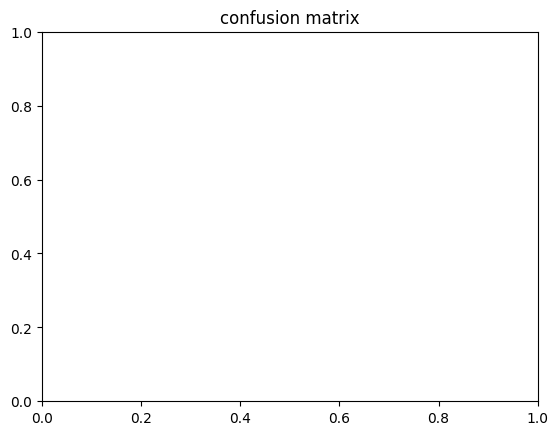

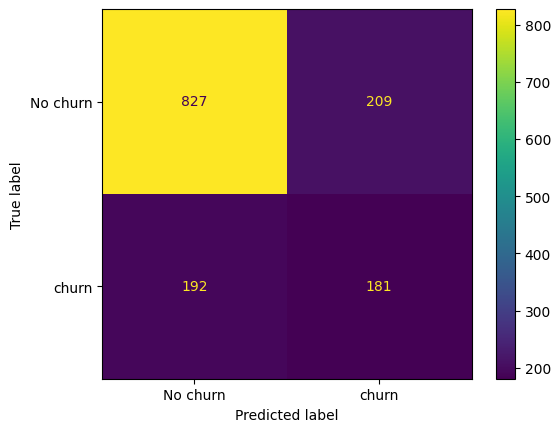

Correctly caught churners (TP): 181
Missed churners (FN): 192


In [46]:
#task11
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm=confusion_matrix(y_test,model_prediction)
display=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No churn','churn'])

plt.title("confusion matrix")
display.plot()
plt.show()

print("Correctly caught churners (TP):", cm[1, 1])
print("Missed churners (FN):", cm[1, 0])

#task12
since dataset has class imbalance, accuracy alone is not measure the reliable model performance. i would focus more on recall and f1 score, especially recall because identifying how many actuall churn are detected by a model and how many are missed is important for customer retension. The model is correctly detected 181 churns but missed 192, showing that significant room for improvement.

In [47]:
#Part 6 — Overfitting Investigation
#task13
train_accuracy=accuracy_score(y_train,model_pred_training)
test_accuracy=accuracy_score(y_test,model_prediction)

print("Training Accuracy", train_accuracy*100)
print("Test Accuracy", test_accuracy*100)

Training Accuracy 99.85800496982606
Test Accuracy 71.5400993612491


the tree has learned depth extremely well on training data but it drops performance on testing data, in other words, it has learned some patterns that dont generalize well.

In [48]:
#task14
depths=[2,3,4,5,6,8,10,None]
results=[]
for depth in depths:
    tree=DecisionTreeClassifier(max_depth=depth,random_state=42)
    tree.fit(X_train,y_train)
    train_accuracy=accuracy_score(y_train,tree.predict(X_train))
    test_accuracy=accuracy_score(y_test,tree.predict(X_test))

    results.append({
        "max_depth": depth,
        "train accuracy": train_accuracy,
        "test accuracy": test_accuracy
    })
results_df=pd.DataFrame(results)
print(results_df)

   max_depth  train accuracy  test accuracy
0        2.0        0.758431       0.778566
1        3.0        0.788960       0.795600
2        4.0        0.795882       0.794180
3        5.0        0.799787       0.799858
4        6.0        0.810614       0.804116
5        8.0        0.837948       0.781405
6       10.0        0.875577       0.764372
7        NaN        0.998580       0.715401


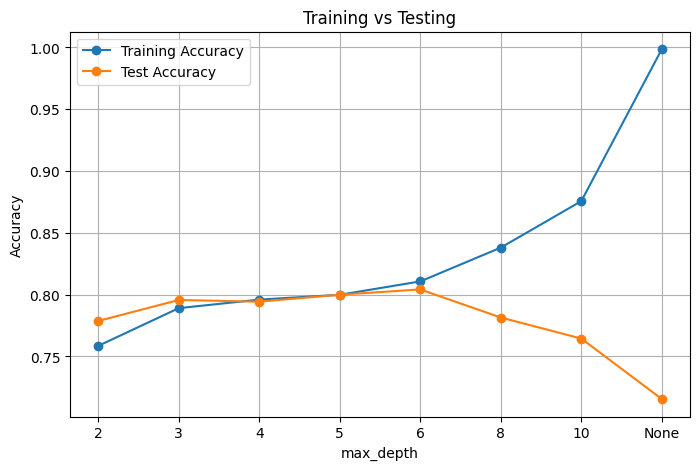

In [49]:
#task15
x_labels=["2","3","4","5","6","8","10","None"]
plt.figure(figsize=(8,5))
plt.plot(x_labels, results_df["train accuracy"], marker="o", label="Training Accuracy")
plt.plot(x_labels, results_df["test accuracy"], marker="o", label="Test Accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Training vs Testing")
plt.legend()
plt.grid(True)

plt.show()

Overfitting starts around depth 6, because after depth 5, training accuracy continues to improve while test accuracy begins to decline.

In [50]:
#Part 7 — Model Selection, Feature Importance & Interpretation
#task16
print(results_df)

   max_depth  train accuracy  test accuracy
0        2.0        0.758431       0.778566
1        3.0        0.788960       0.795600
2        4.0        0.795882       0.794180
3        5.0        0.799787       0.799858
4        6.0        0.810614       0.804116
5        8.0        0.837948       0.781405
6       10.0        0.875577       0.764372
7        NaN        0.998580       0.715401


I selected max_depth = 5 because it provides a strong test accuracy while keeping the gap between training and test accuracy relatively small. Deeper trees improve training performance but begin to reduce test performance, indicating overfitting.

In [51]:
#task17
best_depth=5
best_model=DecisionTreeClassifier(max_depth=best_depth, random_state=42)
best_model.fit(X_train,y_train)
best_pred=best_model.predict(X_test)

accuracy=accuracy_score(y_test, best_pred)
recall=recall_score(y_test, best_pred)
f1=f1_score(y_test, best_pred)
precision=precision_score(y_test, best_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Accuracy : 0.7998580553584103
Precision: 0.618798955613577
Recall   : 0.6353887399463807
F1-score : 0.626984126984127


In [52]:
comparison=pd.DataFrame({
    "Metrics":["Accuracy", "Precision", "Recall", "F1-score"],
    "Baseline":[
        accuracy_score(y_test, model_prediction),
        precision_score(y_test, model_prediction),
        recall_score(y_test, model_prediction),
        f1_score(y_test, model_prediction)
    ],
    "chosen model":[
        accuracy,
        precision,
        recall,
        f1
    ]
})
print(comparison)

     Metrics  Baseline  chosen model
0   Accuracy  0.715401      0.799858
1  Precision  0.464103      0.618799
2     Recall  0.485255      0.635389
3   F1-score  0.474443      0.626984


In [53]:
#task18
entropy_model=DecisionTreeClassifier(max_depth=best_depth, criterion="entropy", random_state=42)
entropy_model.fit(X_train,y_train)
entropy_pred=entropy_model.predict(X_test)

entropy_accuracy = accuracy_score(y_test, entropy_pred)
entropy_precision = precision_score(y_test, entropy_pred)
entropy_recall = recall_score(y_test, entropy_pred)
entropy_f1 = f1_score(y_test, entropy_pred)

print("Accuracy :", entropy_accuracy)
print("Precision:", entropy_precision)
print("Recall   :", entropy_recall)
print("F1-score :", entropy_f1)

Accuracy : 0.7991483321504613
Precision: 0.6222826086956522
Recall   : 0.613941018766756
F1-score : 0.6180836707152496


In [54]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    
    "Baseline": [
        accuracy_score(y_test, model_prediction),
        precision_score(y_test, model_prediction),
        recall_score(y_test, model_prediction),
        f1_score(y_test, model_prediction)
    ],
    
    "Chosen Gini": [
        accuracy,
        precision,
        recall,
        f1
    ],
    
    "Entropy": [
        entropy_accuracy,
        entropy_precision,
        entropy_recall,
        entropy_f1
    ]
})

print(comparison)

      Metric  Baseline  Chosen Gini   Entropy
0   Accuracy  0.715401     0.799858  0.799148
1  Precision  0.464103     0.618799  0.622283
2     Recall  0.485255     0.635389  0.613941
3   F1-score  0.474443     0.626984  0.618084


In [55]:
#task19
importances=best_model.feature_importances_

feature_importance=pd.Series(importances,index=X_train.columns).sort_values(ascending=False).head(5)

print(feature_importance)

Contract_Month-to-month        0.507129
tenure                         0.190375
InternetService_Fiber optic    0.139090
TotalCharges                   0.029322
MonthlyCharges                 0.029056
dtype: float64


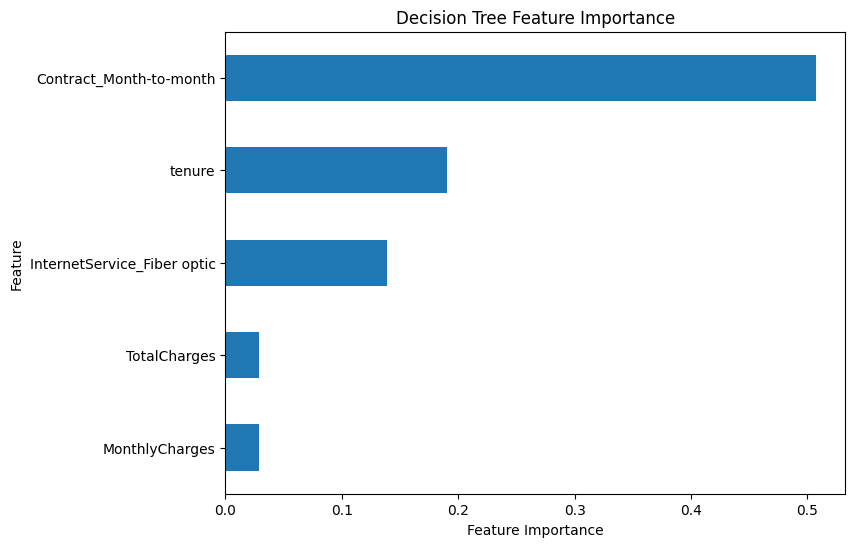

In [56]:
plt.figure(figsize=(8,6))
feature_importance.sort_values().plot(kind="barh")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")
plt.show()

** Part 7 — Model Selection, Feature Importance & Interpretation **
#task20
The most important features identified by the Decision Tree are consistent with the patterns observed during EDA. In Lab 2, contract type, tenure, and monthly charges showed noticeable relationships with churn, and these features were also highly important to the model. This suggests that the model is learning patterns that were already visible in the exploratory analysis.

#task21
In this lab, I built a Decision Tree model to predict customer churn from the Telco dataset. I selected the tree depth that gave a good balance between training and test performance without too much overfitting. The model performed reasonably well based on its accuracy, precision, recall, and F1-score. However, the model still has limitations, especially because the churn classes are imbalanced and deeper trees can easily overfit. Overall, this lab helped me understand how to evaluate and improve a Decision Tree model in a practical way.


#task 22
If I had more time, I would try other machine learning algorithms and compare their results with the Decision Tree. I would also improve the features to see if they can help the model predict churn better. Since the dataset has an imbalance between churn and non-churn customers, I would try techniques to handle class imbalance. This could improve the model’s ability to identify customers who are likely to leave.


In [23]:
#task23
import math
data = {
    'Outlook': [
        'Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain',
        'Rain', 'Overcast', 'Sunny', 'Sunny', 'Rain',
        'Sunny', 'Overcast', 'Overcast', 'Rain'
    ],
    'Temperature': [
        'Hot', 'Hot', 'Hot', 'Mild', 'Cool',
        'Cool', 'Cool', 'Mild', 'Cool', 'Mild',
        'Mild', 'Mild', 'Hot', 'Mild'
    ],
    'Humidity': [
        'High', 'High', 'High', 'High', 'Normal',
        'Normal', 'Normal', 'High', 'Normal', 'Normal',
        'Normal', 'High', 'Normal', 'High'
    ],
    'Wind': [
        'Weak', 'Strong', 'Weak', 'Weak', 'Weak',
        'Strong', 'Strong', 'Weak', 'Weak', 'Weak',
        'Strong', 'Strong', 'Weak', 'Strong'
    ],
    'Play': [
        'No', 'No', 'Yes', 'Yes', 'Yes',
        'No', 'Yes', 'No', 'Yes', 'Yes',
        'Yes', 'Yes', 'Yes', 'No'
    ]
}

df=pd.DataFrame(data)
print(df)

     Outlook Temperature Humidity    Wind Play
0      Sunny         Hot     High    Weak   No
1      Sunny         Hot     High  Strong   No
2   Overcast         Hot     High    Weak  Yes
3       Rain        Mild     High    Weak  Yes
4       Rain        Cool   Normal    Weak  Yes
5       Rain        Cool   Normal  Strong   No
6   Overcast        Cool   Normal  Strong  Yes
7      Sunny        Mild     High    Weak   No
8      Sunny        Cool   Normal    Weak  Yes
9       Rain        Mild   Normal    Weak  Yes
10     Sunny        Mild   Normal  Strong  Yes
11  Overcast        Mild     High  Strong  Yes
12  Overcast         Hot   Normal    Weak  Yes
13      Rain        Mild     High  Strong   No


In [24]:
def entropy(labels):
    counts=labels.value_counts()
    total=len(labels)

    entropy_value=0
    for count in counts:
        probability=count/total
        entropy_value-=probability*math.log2(probability)

    return entropy_value

In [25]:
print("Dataset entropy", entropy(df["Play"]))

Dataset entropy 0.9402859586706311


In [26]:
def information_gain(df, attribute, target="Play"):
    total_entropy = entropy(df[target])

    weighted_entropy = 0

    for value in df[attribute].unique():
        subset = df[df[attribute] == value]

        weight = len(subset) / len(df)

        weighted_entropy += weight * entropy(subset[target])

    gain = total_entropy - weighted_entropy

    return gain

In [27]:
attributes = ["Outlook", "Temperature", "Humidity", "Wind"]

for attribute in attributes:
    gain = information_gain(df, attribute)
    print(f"Gain({attribute}) = {gain:.4f}")

Gain(Outlook) = 0.2467
Gain(Temperature) = 0.0292
Gain(Humidity) = 0.1518
Gain(Wind) = 0.0481


In [28]:
def id3(df, target, attributes, level=0):
    
    # If all target values are the same
    if len(df[target].unique()) == 1:
        return df[target].iloc[0]

    # If no attributes remain
    if len(attributes) == 0:
        return df[target].mode()[0]

    # Calculate information gain for every attribute
    gains = {}

    print("\n" + "  " * level + "Current node:")
    
    for attribute in attributes:
        gain = information_gain(df, attribute, target)
        gains[attribute] = gain
        print(
            "  " * level +
            f"Gain({attribute}) = {gain:.4f}"
        )

    # Select attribute with highest gain
    best_attribute = max(gains, key=gains.get)

    print("  " * level + f"--> Selected: {best_attribute}")

    tree = {best_attribute: {}}

    remaining_attributes = [
        attr for attr in attributes
        if attr != best_attribute
    ]

    # Create branches
    for value in df[best_attribute].unique():

        subset = df[df[best_attribute] == value]

        print(
            "  " * level +
            f"\nBranch: {best_attribute} = {value}"
        )

        tree[best_attribute][value] = id3(subset,target,remaining_attributes, level + 1)

    return tree

In [29]:
attributes = ["Outlook", "Temperature", "Humidity", "Wind"]

tree = id3(
    df,
    target="Play",
    attributes=attributes
)

print("\nFinal Decision Tree:")
print(tree)


Current node:
Gain(Outlook) = 0.2467
Gain(Temperature) = 0.0292
Gain(Humidity) = 0.1518
Gain(Wind) = 0.0481
--> Selected: Outlook

Branch: Outlook = Sunny

  Current node:
  Gain(Temperature) = 0.5710
  Gain(Humidity) = 0.9710
  Gain(Wind) = 0.0200
  --> Selected: Humidity
  
Branch: Humidity = High
  
Branch: Humidity = Normal

Branch: Outlook = Overcast

Branch: Outlook = Rain

  Current node:
  Gain(Temperature) = 0.0200
  Gain(Humidity) = 0.0200
  Gain(Wind) = 0.9710
  --> Selected: Wind
  
Branch: Wind = Weak
  
Branch: Wind = Strong

Final Decision Tree:
{'Outlook': {'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}, 'Overcast': 'Yes', 'Rain': {'Wind': {'Weak': 'Yes', 'Strong': 'No'}}}}
